本文档是实现由720秒的矢量磁图，转化成Bxyz，再转化成Br Btheta Bphi的过程

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from scipy.io import readsav
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from astropy.wcs import WCS
from astropy.wcs.utils import pixel_to_skycoord

<font color=cyan>这一步是转化成Bxyz,参考了郭老师'01plot_hmi.pro'的代码</font>

In [19]:
hmi_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_720s\\'
B_map   = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.field.fits')
inc_map = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.inclination.fits')
azi_map = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.azimuth.fits')
dis_map = sunpy.map.Map(hmi_path + 'hmi.B_720s.20240618_211200_TAI.disambig.fits')

B   = B_map.data
inc = inc_map.data   # degree
azi = azi_map.data   # degree
dis = dis_map.data

# === 2. 处理 180° ambiguity ===
# IDL: if disambig > 3 → azimuth + 180°
mask = dis > 3
azi = azi.copy()
azi[mask] += 180.0

# === 3. 角度转弧度 ===
inc_rad = np.deg2rad(inc)
azi_rad = np.deg2rad(azi+270)   # ⚠️ 非常关键（IDL中的定义）

# === 4. 计算 Bxyz（未 rotate）===
Bz = B * np.cos(inc_rad)
Bx = B * np.sin(inc_rad) * np.cos(azi_rad)
By = B * np.sin(inc_rad) * np.sin(azi_rad)

# === 5. IDL rotate(...,2) → 180°翻转 ===
Bz = np.rot90(Bz, 2)
Bx = np.rot90(Bx, 2)
By = np.rot90(By, 2)

# === 6. 处理异常值（对应 IDL）===
mask_bad = Bx <= -10000.0
Bx[mask_bad] = 0.0
By[mask_bad] = 0.0

<font color=cyan>接下来转化到Br theta phi上，转化矩阵参考文章</font>  
《OntheCoordinate Systemof Space-Weather HMIActive Region
Patches (SHARPs): A Technical Note》  
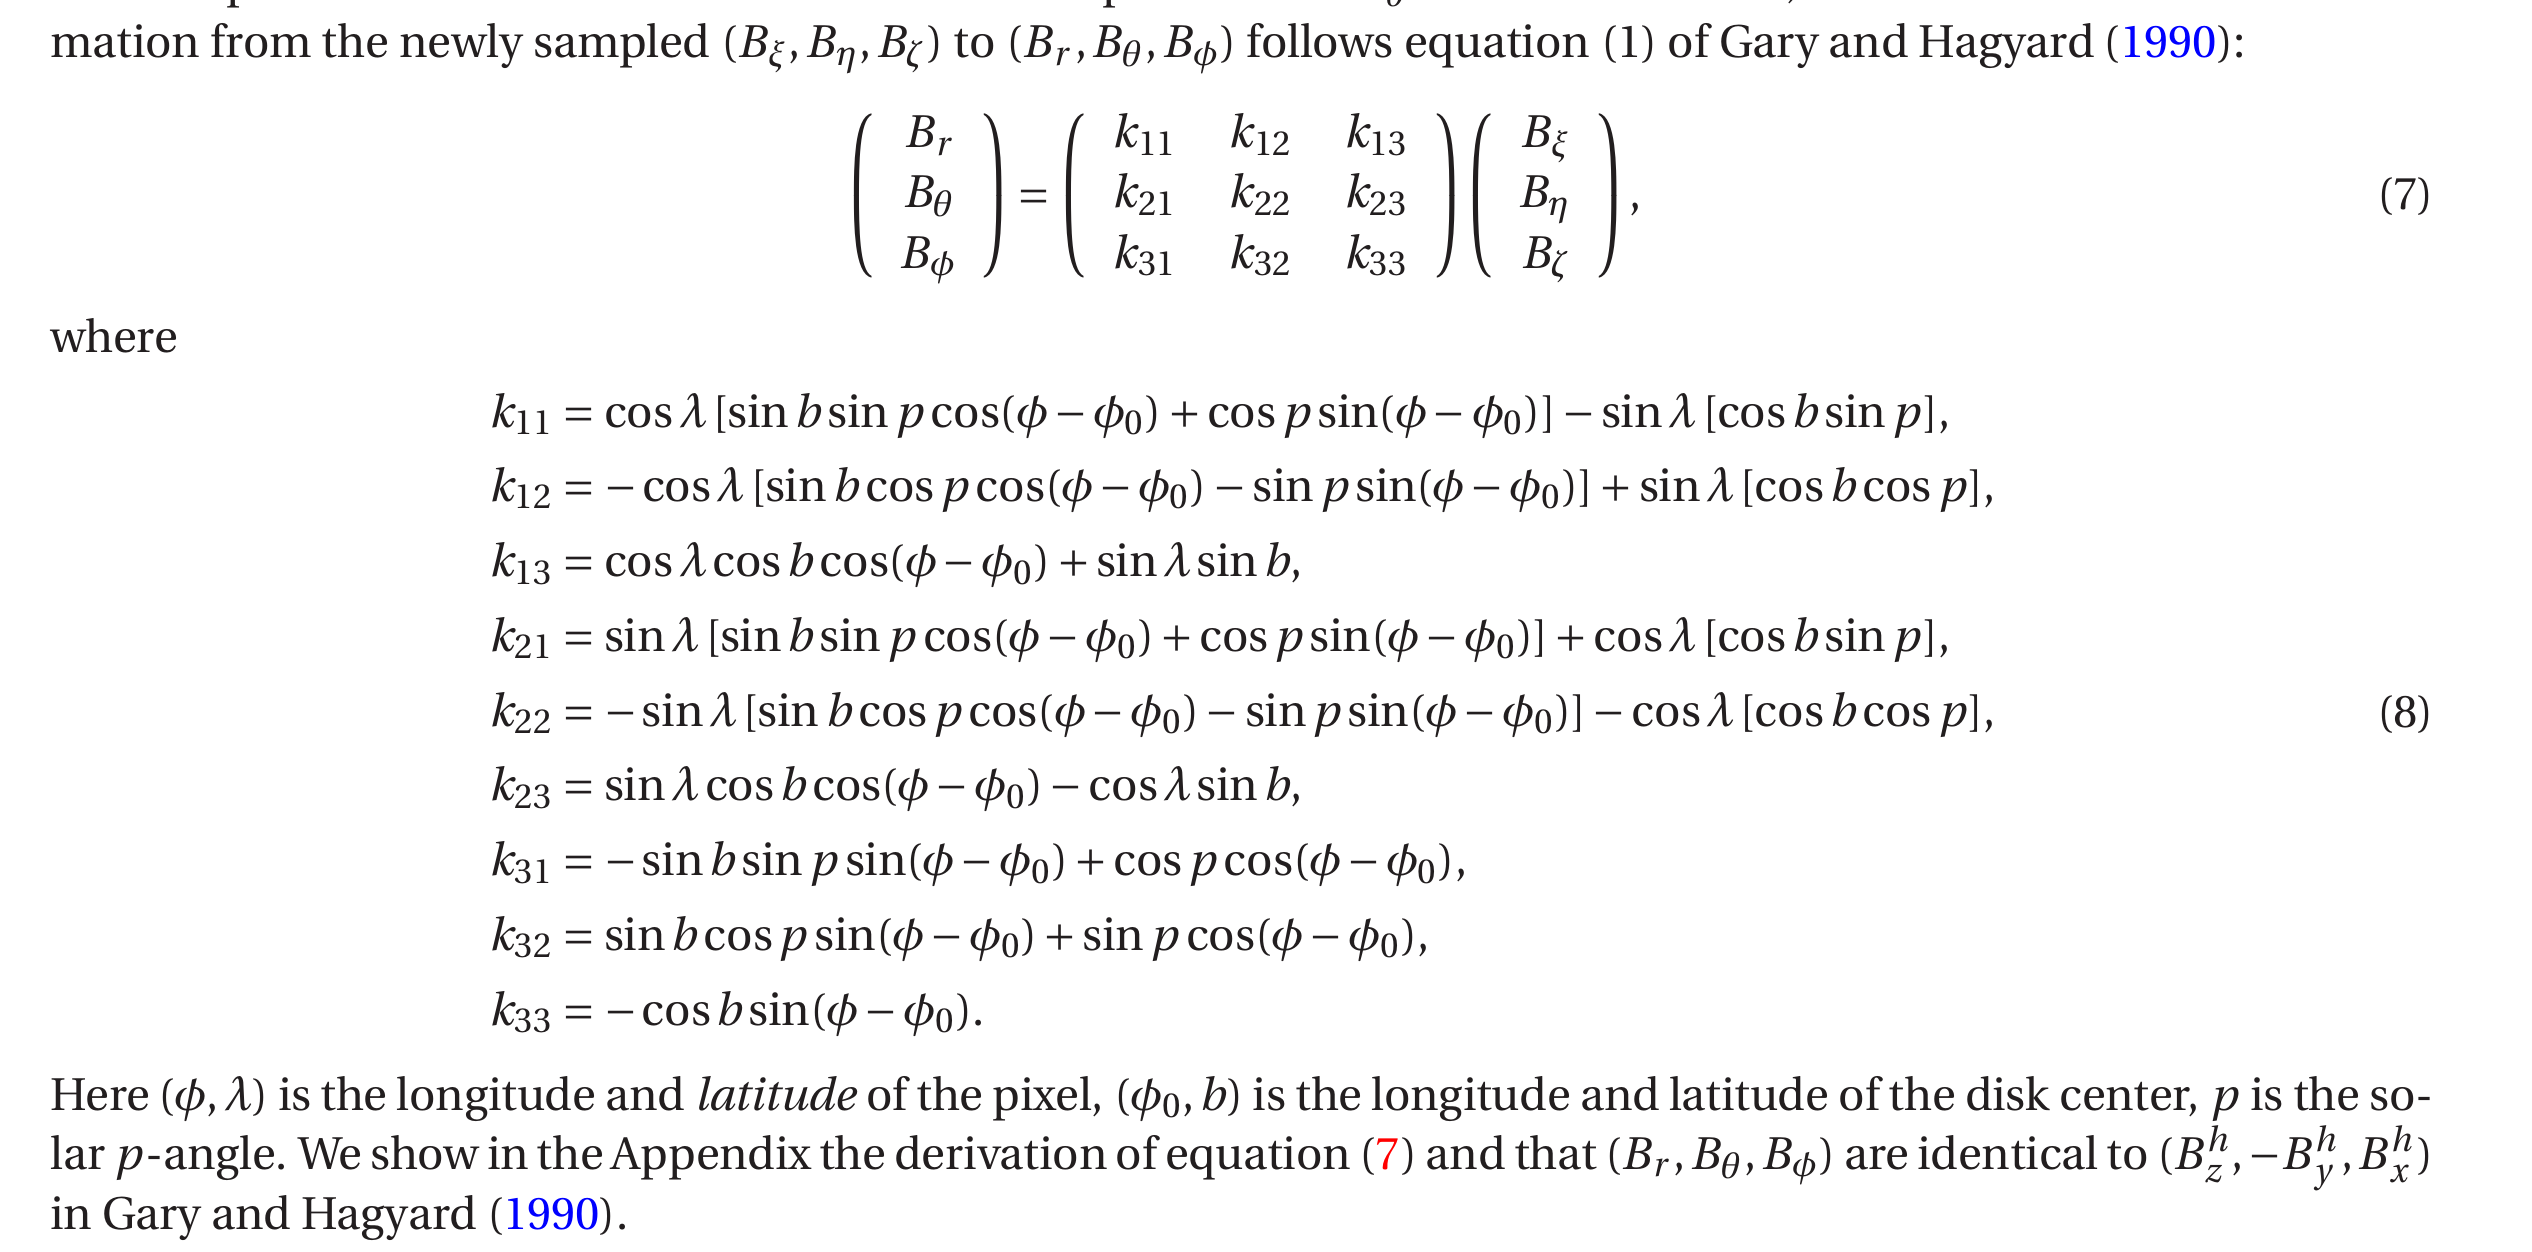  
这里的$B_{\xi}, B_{\eta}, B_{\zeta}$就是Bxyz

In [20]:
#这里需要注意，不要用.rotate(),会产生padding，导致整体变成4098*4098，但是根据郭老师的IDL代码计算Bxyz的时候是4096*4096没有填充的
hmi_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_720s\\'
B_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.field.fits')
inc_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.inclination.fits')
azi_map=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.azimuth.fits')

In [ ]:
phi0 = B_map.observer_coordinate.lon.to(u.rad).value
b    = B_map.observer_coordinate.lat.to(u.rad).value
# WCS rotation matrix
pc = B_map.wcs.wcs.pc

# P-angle（弧度）
p = np.arctan2(pc[0,1], pc[0,0])
# 2 像素坐标
ny,nx = B_map.data.shape
y,x = np.mgrid[0:ny,0:nx]

# 3 skycoord
coords = pixel_to_skycoord(x,y,B_map.wcs)

# 4 heliographic
hg = coords.transform_to(frames.HeliographicStonyhurst)

phi = hg.lon.to(u.rad).value
lam = hg.lat.to(u.rad).value
#这一小段就对应没有进行.rotate，所以角度要换一下
#要不然图像从左到右X的坐标是从＋1000角秒到-1000角秒的，Y也是，Br的值变成相反数了
phi=phi+np.pi
phi=np.mod(phi, 2*np.pi)
lam=-lam

In [27]:
#计算矩阵参数
dphi = phi - phi0

k11 = np.cos(lam)*(np.sin(b)*np.sin(p)*np.cos(dphi) + np.cos(p)*np.sin(dphi)) \
      - np.sin(lam)*(np.cos(b)*np.sin(p))

k12 = -np.cos(lam)*(np.sin(b)*np.cos(p)*np.cos(dphi) - np.sin(p)*np.sin(dphi)) \
      + np.sin(lam)*(np.cos(b)*np.cos(p))

k13 = np.cos(lam)*np.cos(b)*np.cos(dphi) + np.sin(lam)*np.sin(b)


k21 = np.sin(lam)*(np.sin(b)*np.sin(p)*np.cos(dphi) + np.cos(p)*np.sin(dphi)) \
      + np.cos(lam)*(np.cos(b)*np.sin(p))

k22 = -np.sin(lam)*(np.sin(b)*np.cos(p)*np.cos(dphi) - np.sin(p)*np.sin(dphi)) \
      - np.cos(lam)*(np.cos(b)*np.cos(p))

k23 = np.sin(lam)*np.cos(b)*np.cos(dphi) - np.cos(lam)*np.sin(b)


k31 = -np.sin(b)*np.sin(p)*np.sin(dphi) + np.cos(p)*np.cos(dphi)

k32 =  np.sin(b)*np.cos(p)*np.sin(dphi) + np.sin(p)*np.cos(dphi)

k33 = -np.cos(b)*np.sin(dphi)

In [28]:
Br =(k11*Bx + k12*By + k13*Bz)
Btheta = k21*Bx + k22*By + k23*Bz
Bphi = k31*Bx + k32*By + k33*Bz

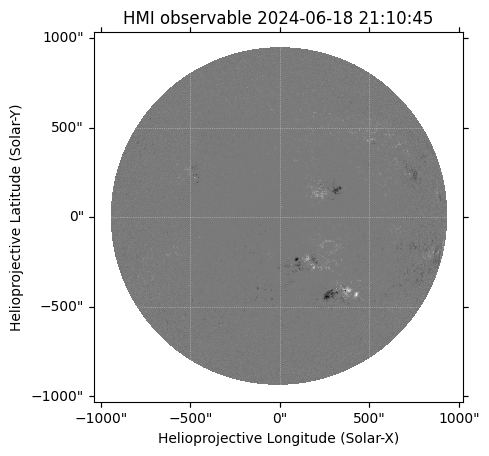

In [29]:
B_map_rot=sunpy.map.Map(hmi_path+'hmi.B_720s.20240618_211200_TAI.field.fits').rotate()
Br_map=sunpy.map.Map(Br,B_map_rot.meta)
Br_map.plot()
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=Br_map.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=Br_map.coordinate_frame)

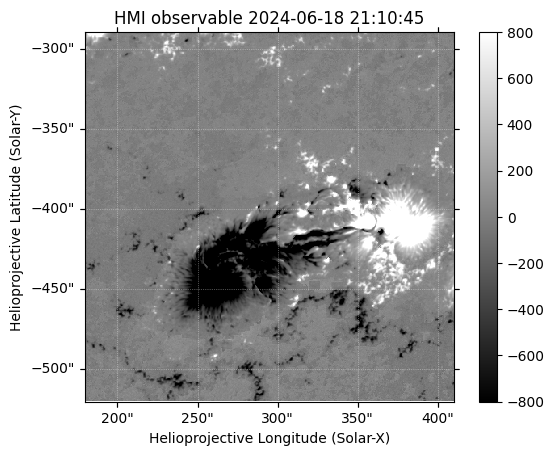

In [30]:
sub_map=Br_map.submap(bottom_left,top_right=top_right)
im=sub_map.plot()
im.set_clim(-800,800)
plt.colorbar(im)

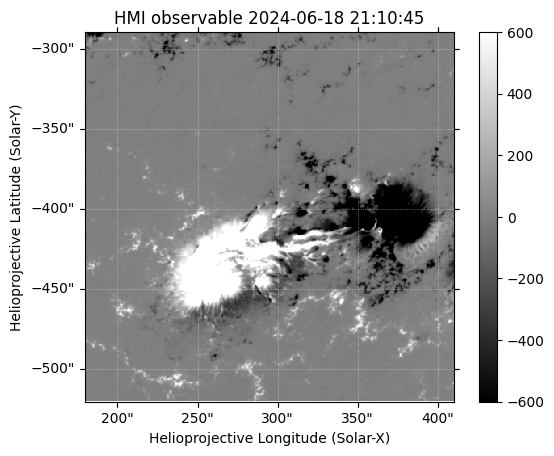

In [23]:
Bz_map=sunpy.map.Map(Bz,B_map_rot.meta)
sub_Bz_map=Bz_map.submap(bottom_left,top_right=top_right)
im_Bz=sub_Bz_map.plot()
im_Bz.set_clim(-600,600)
plt.colorbar(im_Bz)

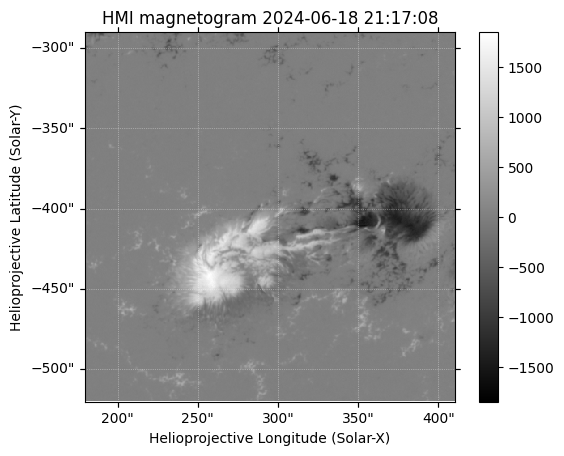

In [20]:
map4=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\hmi.M_45s.20240618_211800_TAI.2.magnetogram.fits').rotate()
sub_map4=map4.submap(bottom_left,top_right=top_right)
im_map4=sub_map4.plot()
plt.colorbar(im_map4)

dict_keys(['mapbx', 'mapby', 'mapbz'])


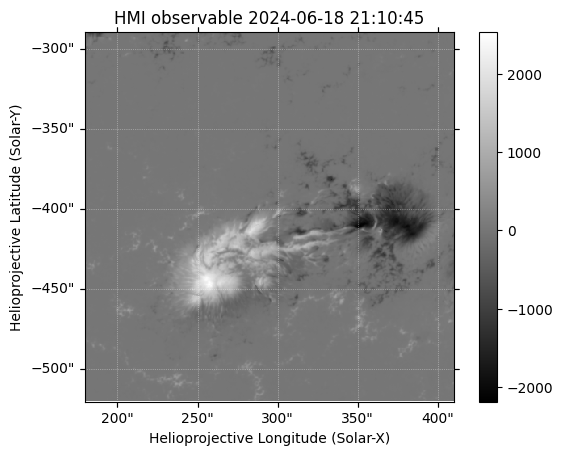

In [27]:
d= readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI4\bxyz_map.sav')
# IDL 变量名在 Python 里通常会变成小写
print(d.keys())   # 先看实际键名

mapbx = d["mapbx"][0][0]
mapby = d["mapby"][0][0]
mapbz = d["mapbz"][0][0]

Bz_idl_map=sunpy.map.Map(mapbz,B_map_rot.meta)
sub_Bz_idl_map=Bz_idl_map.submap(bottom_left,top_right=top_right)
im_Bz_idl=sub_Bz_idl_map.plot()
plt.colorbar(im_Bz_idl)

In [55]:
print(Br[2048,2048],Bz[2048,2048],mapbz[2048,2048])

3.8144222901291482 -3.8652501109398925 -3.8652549


In [28]:
print(sub_Bz_idl_map.data.mean())
print(sub_Bz_map.data.mean())
print(sub_map4.data.mean())

4.761235
4.76122477582115
4.2502537690177435


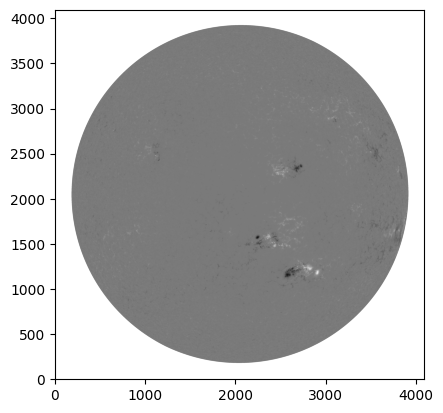

In [8]:
plt.imshow(Br,origin='lower',cmap='gray')